# Анализ инвестиций в стартапы

## Цель и задачи  

**Цель:** исследовать динамику и структуру финансирования стартапов и ответить на вопросы, важные для оценки инвестиционных стратегий.   

**Задачи:**
1. Провести предобработку данных, убрать дубликаты и пропуски, проверить корректность числовых и временных значений.
2. Выделить группы компаний по срокам финансирования и сравнить их по количеству и объёму инвестиций.
3. Классифицировать сегменты рынка на массовые, средние и нишевые и учесть это в дальнейшем анализе.
4. Определить типичные и аномальные значения объёмов финансирования, исключить выбросы и ограничить период исследования.
5. Сравнить популярность и объёмы разных типов финансирования.
6. Проанализировать динамику раундов и объёмов инвестиций по годам, а также изменения в массовых сегментах рынка.
7. Рассчитать долю возврата средств для разных типов финансирования и оценить её устойчивость.
8. Подвести итоговые выводы и дать рекомендации, куда и каким образом было бы целесообразно инвестировать, если бы на дворе был 2015 год.

## Данные

Использованы два набора данных:

- Информация о стартапах и раундах финансирования
- Данные о возврате инвестиций по типам финансирования

Данные использованы в рамках учебного проекта и не публикуются.


## Структура проекта

1. Загрузка данных и знакомство с ними.
2. Предобработка данных.
3. Исследовательский анализ данных.
4. Итоговые выводы и рекомендации.

---


# 1. Знакомство с данными: загрузка и предобработка

## 1.1. Загрузка и первичный анализ данных

В проекте используются два набора данных:

- Информация о стартапах и раундах финансирования
- Данные о возврате инвестиций по типам финансирования

На данном этапе выполнена загрузка данных и проведён первичный анализ структуры датасетов.

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
import os

if os.path.exists('cb_investments.csv') and os.path.exists('cb_returns.csv'):
    cb_investments = pd.read_csv('cb_investments.csv', sep=';', low_memory=False)
    cb_returns = pd.read_csv('cb_returns.csv')
else:
    print('Файлы данных не найдены. Добавьте cb_investments.csv и cb_returns.csv')

Первичный осмотр данных:

In [3]:
cb_investments.head()

,name,homepage_url,category_list,market,funding_total_usd,status,country_code,state_code,region,city,...,secondary_market,product_crowdfunding,round_A,round_B,round_C,round_D,round_E,round_F,round_G,round_H
0,Harvard University,http://harvard.edu,|Education|,Education,"9,00,00,000",operating,USA,MA,Boston,Cambridge,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,University of New Brunswick,http://www.unb.ca,NaN,NaN,"20,00,000",operating,NaN,NaN,NaN,NaN,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,DuPont,http://www.dupont.com,|Business Services|Agriculture|Automotive|Inve...,Business Services,"90,00,000",operating,USA,DE,"Wilmington, Delaware",Wilmington,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,University of Michigan,http://www.umich.edu/,|Education|,Education,"77,00,000",operating,USA,MI,Detroit,Ann Arbor,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,Case Western Reserve University,http://www.case.edu,|Education|,Education,"5,40,000",operating,USA,OH,Cleveland,Cleveland,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [4]:
cb_investments.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 54294 entries, 0 to 54293
Data columns (total 40 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   name                  49437 non-null  object 
 1   homepage_url          45989 non-null  object 
 2   category_list         45477 non-null  object 
 3    market               45477 non-null  object 
 4    funding_total_usd    49438 non-null  object 
 5   status                48124 non-null  object 
 6   country_code          44165 non-null  object 
 7   state_code            30161 non-null  object 
 8   region                44165 non-null  object 
 9   city                  43322 non-null  object 
 10  funding_rounds        49438 non-null  float64
 11  participants          30473 non-null  float64
 12  founded_at            38554 non-null  object 
 13  founded_month         38482 non-null  object 
 14  founded_quarter       38482 non-null  object 
 15  founded_year       


После первичного анализа выявлены следующие особенности данных:

- В названиях столбцов market и funding_total_usd присутствуют лишние пробелы, требующие удаления

- Признак funding_total_usd имеет тип object, несмотря на числовую природу. Значения содержат запятые и требуют приведения к числовому формату


- Признак status может быть преобразован в категориальный тип

- Признаки funding_rounds и participants должны содержать целочисленные значения, однако имеют тип float, вероятно из-за наличия пропусков

Признаки, связанные с датами, представлены в некорректном формате (object или float) и требуют приведения к соответствующим типам:

- даты (*_at) — к типу datetime

- год (founded_year) — к типу Int64

- месяц и квартал — к типу datetime


Во всех признаках присутствуют пропуски, которые будут дополнительно проанализированы на этапе предобработки.

Проведён первичный осмотр датасета с данными о возврате инвестиций:

In [5]:
cb_returns.head()

,year,seed,venture,equity_crowdfunding,undisclosed,convertible_note,debt_financing,angel,grant,private_equity,post_ipo_equity,post_ipo_debt,secondary_market,product_crowdfunding
0,2000,16.70,55.40,0.0,78.21,0.00,8.66,6.43,0.0,0.00,0.94,0.0,0.20,0.0
1,2001,2.88,23.49,0.0,21.50,0.01,4.49,1.18,0.0,0.00,0.46,0.0,0.46,0.0
2,2002,6.59,209.42,0.0,25.77,0.02,3.42,3.41,0.0,1.51,0.34,0.0,0.06,0.0
3,2003,7.74,233.86,0.0,9.40,0.01,1.09,3.41,0.0,1.62,2.11,0.0,0.08,0.0
4,2004,9.93,555.90,0.0,33.19,0.01,13.55,9.18,0.0,2.19,3.38,0.0,0.55,0.0


In [6]:
cb_returns.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15 entries, 0 to 14
Data columns (total 14 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   year                  15 non-null     int64  
 1   seed                  15 non-null     float64
 2   venture               15 non-null     float64
 3   equity_crowdfunding   15 non-null     float64
 4   undisclosed           15 non-null     float64
 5   convertible_note      15 non-null     float64
 6   debt_financing        15 non-null     float64
 7   angel                 15 non-null     float64
 8   grant                 15 non-null     float64
 9   private_equity        15 non-null     float64
 10  post_ipo_equity       15 non-null     float64
 11  post_ipo_debt         15 non-null     float64
 12  secondary_market      15 non-null     float64
 13  product_crowdfunding  15 non-null     float64
dtypes: float64(13), int64(1)
memory usage: 1.8 KB


Датасет содержит 15 строк (лет наблюдений) и 14 столбцов с информацией о возврате инвестиций по типам финансирования.

В ходе первичного анализа установлено:

- Признак year представляет временную шкалу

- Остальные признаки отражают объёмы возврата инвестиций по различным типам финансирования

- Типы данных заданы корректно:

  
    year — целочисленный признак

  
    остальные признаки — вещественные числовые значения

Данные являются полностью структурированными:

- пропуски отсутствуют
- 
- преобразование типов не требуется

Датасет готов к дальнейшему анализу.

## Предобработка данных


Наличие лишних пробелов может приводить к ошибкам при обращении к признакам

In [7]:
cb_investments.columns = cb_investments.columns.str.strip()


Уберем в столбце funding_total_usd выделение разрядов и приведем его к числовому типу.

In [8]:
#Посмотрим сначала на данные в столбце, которые не являются числами

converted = pd.to_numeric(
    cb_investments['funding_total_usd'].str.replace(',', '', regex=False),
    errors='coerce'
)

cb_investments.loc[converted.isna(), 'funding_total_usd'].unique()

array([' -   ', nan], dtype=object)

Убираем запятые, нечисловые значения меняем на nan

In [9]:
cb_investments['funding_total_usd'] = (
    cb_investments['funding_total_usd']
    .str.strip()                      # убираем пробелы в ' -  ' 
    .replace('-', None)               # заменяем '-' на NaN
    .str.replace(',', '', regex=False)
)

cb_investments['funding_total_usd'] = pd.to_numeric(
    cb_investments['funding_total_usd'],
    errors='coerce'
)

Посмотрим какие значение есть в толбце status

In [10]:
cb_investments['status'].value_counts(dropna=False)

status
operating    41829
NaN           6170
acquired      3692
closed        2603
Name: count, dtype: int64

Сделаем столбец status категориальным типом:

In [11]:
cb_investments['status'] = cb_investments['status'].astype('category')

Теперь приведем к целочисленному типу данных столбцы funding_rounds (общее число раундов финансирования) и participants (число участников в раундах финансирования):

Сделаем проверку на остаток от деления на 1 по столбцу participants

In [12]:
participants_rest = cb_investments['participants'].notna() & (cb_investments['participants'] % 1 != 0)

participants_rest.sum()

np.int64(0)

Сделаем проверку на остаток от деления на 1 по столбцу funding_rounds

In [13]:
funding_rounds_test = cb_investments['funding_rounds'].notna() & (cb_investments['funding_rounds'] % 1 != 0)

funding_rounds_test.sum()

np.int64(0)

Столбцы funding_rounds и participants сордерджат только целые числа и пропуски.

Приведем данные к целочисленному типу

In [14]:
cb_investments['funding_rounds'] = cb_investments['funding_rounds'].round().astype('Int64')
cb_investments['participants'] = cb_investments['participants'].round().astype('Int64')

Теперь поменяем тип данных в след столбцах:

- founded_at — дата основания компании;
- founded_month — месяц основания в формате YYYY-MM;
- founded_quarter — квартал основания в формате YYYY-QN;
- founded_year — год основания;
- first_funding_at — дата первого финансирования;
- mid_funding_at — дата среднего по времени раунда финансирования;
- last_funding_at — дата последнего финансирования;

In [15]:
#Посмотрим как выглядят данные в первых 5 строках в этих столбцах
cb_investments[[
    'founded_at',
    'first_funding_at',
    'mid_funding_at',
    'last_funding_at'
]].head()

,founded_at,first_funding_at,mid_funding_at,last_funding_at
0,1636-09-08,2014-01-06,NaN,2014-01-06
1,1785-01-01,2014-05-15,NaN,2014-05-15
2,1802-07-19,2009-07-02,2009-07-02,2009-07-02
3,1817-01-01,2013-11-21,2013-11-21,2014-11-03
4,1826-01-01,2014-01-14,NaN,2014-01-14


Меняем тип данных:

In [16]:
date_cols = [
    'founded_at',
    'first_funding_at',
    'mid_funding_at',
    'last_funding_at'
]

for col in date_cols:
    cb_investments[col] = pd.to_datetime(
    cb_investments[col],
    format='%Y-%m-%d',
    errors='coerce'
)

In [17]:
#Проверим формат записи данных в стобце founded_month
cb_investments[cb_investments['founded_month'].notna()]['founded_month']

72       1902-01
73       1902-01
74       1903-01
75       1905-01
76       1906-01
          ...   
38549    2014-11
38550    2014-11
38551    2014-11
38552    2014-12
38553    2014-12
Name: founded_month, Length: 38482, dtype: object

Меняем тип данных в столбце founded_month

In [18]:
cb_investments['founded_month'] = pd.to_datetime(
    cb_investments['founded_month'],
    format='%Y-%m',
    errors='coerce'
)

In [19]:
#Проверим формат записи данных в стобце founded_quarter
cb_investments[cb_investments['founded_quarter'].notna()]['founded_quarter']

72       1902-Q1
73       1902-Q1
74       1903-Q1
75       1905-Q1
76       1906-Q1
          ...   
38549    2014-Q4
38550    2014-Q4
38551    2014-Q4
38552    2014-Q4
38553    2014-Q4
Name: founded_quarter, Length: 38482, dtype: object

Меняем тип данных в столбце founded_quarter

In [20]:
# Меняем кварталы на первые месяцы в кварталах

cb_investments['founded_quarter'] = (
    cb_investments['founded_quarter']
    .str.replace('Q1', '-01')
    .str.replace('Q2', '-04')
    .str.replace('Q3', '-07')
    .str.replace('Q4', '-10')
)

# Меняем тип данных
cb_investments['founded_quarter'] = pd.to_datetime(
    cb_investments['founded_quarter'],
    format='%Y-%m',
    errors='coerce'
)

In [21]:
#Проверим формат записи данных в стобце founded_month
cb_investments[cb_investments['founded_year'].notna()]['founded_year']

0        1636.0
1        1785.0
2        1802.0
3        1817.0
4        1826.0
          ...  
38549    2014.0
38550    2014.0
38551    2014.0
38552    2014.0
38553    2014.0
Name: founded_year, Length: 38554, dtype: float64

Меняем тип данных в столбце founded_year на Int64

In [22]:
cb_investments['founded_year'] = cb_investments['founded_year'].astype('Int64')

In [23]:
cb_investments.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 54294 entries, 0 to 54293
Data columns (total 40 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   name                  49437 non-null  object        
 1   homepage_url          45989 non-null  object        
 2   category_list         45477 non-null  object        
 3   market                45477 non-null  object        
 4   funding_total_usd     40907 non-null  float64       
 5   status                48124 non-null  category      
 6   country_code          44165 non-null  object        
 7   state_code            30161 non-null  object        
 8   region                44165 non-null  object        
 9   city                  43322 non-null  object        
 10  funding_rounds        49438 non-null  Int64         
 11  participants          30473 non-null  Int64         
 12  founded_at            38553 non-null  datetime64[ns]
 13  founded_month   

Проверим датафрейм на полные дубликаты:

In [24]:
cb_investments.duplicated().sum()

np.int64(4855)

4855 полных дубликатов

Удалим их:

In [25]:
cb_investments = cb_investments.drop_duplicates()

In [26]:
# Проверяем еще раз
cb_investments.duplicated().sum()

np.int64(0)

Проверим пропуски в данных. Узнаем абсолютное и относительное количество пропусков в столбцах с пропусками

In [27]:
cb_investments.isna().sum().sort_values(ascending=False)

founded_quarter         49439
state_code              19278
mid_funding_at          19151
participants            18966
founded_month           10957
founded_at              10886
founded_year            10885
funding_total_usd        8532
city                     6117
region                   5274
country_code             5274
market                   3962
category_list            3962
homepage_url             3450
status                   1315
first_funding_at           11
last_funding_at             7
name                        2
post_ipo_debt               1
round_F                     1
round_G                     1
round_E                     1
round_D                     1
round_C                     1
round_B                     1
round_A                     1
product_crowdfunding        1
secondary_market            1
venture                     1
post_ipo_equity             1
private_equity              1
grant                       1
angel                       1
debt_finan

In [28]:
(cb_investments.isna().sum() / cb_investments.shape[0]*100).sort_values(ascending=False)

founded_quarter         100.000000
state_code               38.993507
mid_funding_at           38.736625
participants             38.362426
founded_month            22.162665
founded_at               22.019054
founded_year             22.017031
funding_total_usd        17.257631
city                     12.372823
region                   10.667691
country_code             10.667691
market                    8.013916
category_list             8.013916
homepage_url              6.978296
status                    2.659843
first_funding_at          0.022250
last_funding_at           0.014159
name                      0.004045
post_ipo_debt             0.002023
round_F                   0.002023
round_G                   0.002023
round_E                   0.002023
round_D                   0.002023
round_C                   0.002023
round_B                   0.002023
round_A                   0.002023
product_crowdfunding      0.002023
secondary_market          0.002023
venture             

Столбец founded_quarter полностью состоит из пропусков. Его можно удалить:

In [29]:
cb_investments = cb_investments.drop(columns=['founded_quarter'])

Пропуски в значениях mid_funding_at заполним на основании значений в столбцах first_funding_at и last_funding_at. В качестве нового значения вместо пропусков возьмем приблизительно середину интервала между этими двумя датами.

In [30]:
mask = cb_investments['mid_funding_at'].isna()

cb_investments.loc[mask, 'mid_funding_at'] = (
    cb_investments.loc[mask, 'first_funding_at'] +
    (cb_investments.loc[mask, 'last_funding_at'] - 
     cb_investments.loc[mask, 'first_funding_at']) / 2
)

In [31]:
#Проверим теперь процент пропусков в столбце mid_funding_at
cb_investments['mid_funding_at'].isna().mean() * 100

np.float64(0.01820425170412023)

Процент пропусков в столбце mid_funding_at снизился с 38.74% до 0.18%

В датасете cb_returns сделаем столбец year индексом всего датасета:

In [32]:
cb_returns = cb_returns.set_index('year')

In [33]:
# Проверяем
cb_returns.head()

,seed,venture,equity_crowdfunding,undisclosed,convertible_note,debt_financing,angel,grant,private_equity,post_ipo_equity,post_ipo_debt,secondary_market,product_crowdfunding
year,,,,,,,,,,,,,
2000,16.70,55.40,0.0,78.21,0.00,8.66,6.43,0.0,0.00,0.94,0.0,0.20,0.0
2001,2.88,23.49,0.0,21.50,0.01,4.49,1.18,0.0,0.00,0.46,0.0,0.46,0.0
2002,6.59,209.42,0.0,25.77,0.02,3.42,3.41,0.0,1.51,0.34,0.0,0.06,0.0
2003,7.74,233.86,0.0,9.40,0.01,1.09,3.41,0.0,1.62,2.11,0.0,0.08,0.0
2004,9.93,555.90,0.0,33.19,0.01,13.55,9.18,0.0,2.19,3.38,0.0,0.55,0.0


В столбце market удалим лишние пробелы и все симболы переведем в нижний регистр

In [34]:
cb_investments['market'] = (
    cb_investments['market']
    .str.strip()
    .str.lower()
)

Результаты предобработки данных:

- В столбце funding_total_usd убрано выделение разрядов (удалены запятые) и данные приведены к числовому типу
- Тип данных в столбце status был изменен на категориальный
- Столбцы funding_rounds (общее число раундов финансирования) и participants (число участников в раундах финансирования) были приведены к целочисленномуц типу данных
- В столбцах founded_at (дата основания компании), founded_month (месяц основания в формате YYYY-MM), first_funding_at (дата первого финансирования), mid_funding_at (дата среднего по времени раунда финансирования), last_funding_at (дата последнего финансирования) тип данных был изменен на datetime
- В столбце founded_year (год основания) тип данных был изменен на Int64;
- Было удалено 4855 полных дубликатов;
- Столбец founded_quarter был удален;
- Пропуски в значениях mid_funding_at были заполнены приблизительной серединой интервала между first_funding_at и last_funding_a.
- В датасете cb_returns столбец year сделали индексом всего датасета
- В столбце market удалили лишние пробелы и все симболы перевели в нижний регистр


# 2. Инжиниринг признаков

## 2.1. Группы по срокам финансирования

Разделим все компании на три группы:
- Единичное финансирование — был всего один раунд финансирования.
- Срок финансирования до года — между первым и последним раундом финансирования прошло не более года.
- Срок финансирования более года.

In [35]:
# Считаем длительность финансирования (если ещё не сделали)
cb_investments['funding_duration'] = (
    cb_investments['last_funding_at'] - cb_investments['first_funding_at']
).dt.days


# Функция для категоризации
def categorize(row):
    if pd.notna(row['funding_rounds']) and row['funding_rounds'] == 1:
        return 'single'
    elif pd.notna(row['funding_duration']) and row['funding_duration'] <= 365:
        return '≤ 1 year'
    elif pd.notna(row['funding_duration']):
        return '> 1 year'
    else:
        return 'unknown'


# Применяем функцию
cb_investments['funding_group'] = cb_investments.apply(categorize, axis=1)


# делаем категориальный тип
cb_investments['funding_group'] = pd.Categorical(
    cb_investments['funding_group'],
    categories=['single', '≤ 1 year', '> 1 year', 'unknown'],
    ordered=True
)

Посмотрим на распределение групп:

In [36]:
# В абсолютном выражении:
cb_investments['funding_group'].value_counts(dropna=False) 

funding_group
single      32039
> 1 year    12608
≤ 1 year     4787
unknown         5
Name: count, dtype: int64

In [37]:
# В относительном выражении в %:
#Сгруппируем компании по столбцу funding_group относительном выражении в %:
share_count = (
    cb_investments['funding_group']
    .value_counts(normalize=True) * 100
)

share_count

funding_group
single      64.805113
> 1 year    25.502134
≤ 1 year     9.682639
unknown      0.010113
Name: proportion, dtype: float64

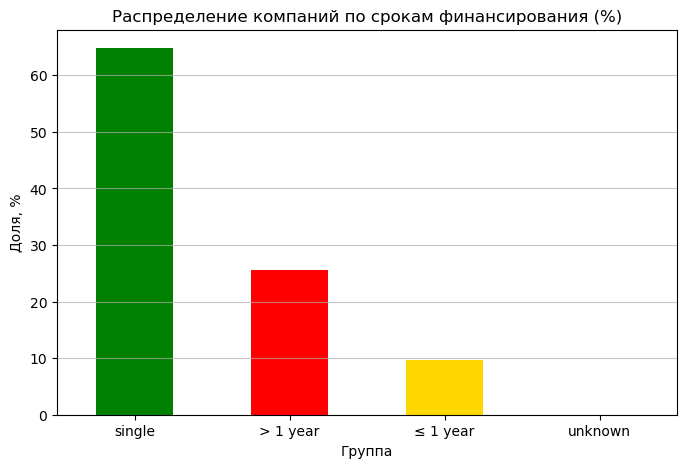

In [38]:
#Зададим цвета для групп:
colors = {
    'single': 'green',
    '≤ 1 year': 'gold',
    '> 1 year': 'red',
    'unknown': 'gray'
}


# Визуализируем соотношение долейц в %:
share_count.plot(
    kind='bar',
    rot=0,
    figsize=(8,5),
    title='Распределение компаний по срокам финансирования (%)',
    color=[colors[i] for i in share_count.index]
)

plt.ylabel('Доля, %')
plt.xlabel('Группа')
plt.grid(axis='y', alpha=0.7)
plt.show()

Большинство компаний (64.8%) получают только один раунд финансирования - группа single. Это означает, что они:

- либо не продолжают привлекать деньги
- либо не проходят дальше ранних стадий

Долгосрочное финансирование - 25,5% компаний привлекают инвестиции более года. Это:

- более зрелые проекты
- проходят несколько раундов
- потенциально более успешные

Краткосрочное финансирование - 9,68% компаний успевает привлечь несколько раундов за срок меньше 1 года. Здесь возможны:
- быстрый рост
- агрессивное инвестирование



Посмотрим теперь на распределение общего объёма привлечённых средств в каждой группе

Распределение в абсолютных значениях в млрд долларах США:

In [39]:
cb_investments.groupby('funding_group', observed=True)['funding_total_usd'].sum().sort_values(ascending=False) / 1e9

funding_group
> 1 year    402.708998
single      199.304424
≤ 1 year     48.885981
unknown       0.034300
Name: funding_total_usd, dtype: float64

Распределение в %:

In [40]:
share_funding = (
    cb_investments
    .groupby('funding_group', observed=True)['funding_total_usd']
    .sum()
    .sort_values(ascending=False)
    / cb_investments['funding_total_usd'].sum()
    * 100
)

share_funding

funding_group
> 1 year    61.866361
single      30.618237
≤ 1 year     7.510132
unknown      0.005269
Name: funding_total_usd, dtype: float64

Визуализируем распределение общего объема инвестиций по срокам финансирования в %:

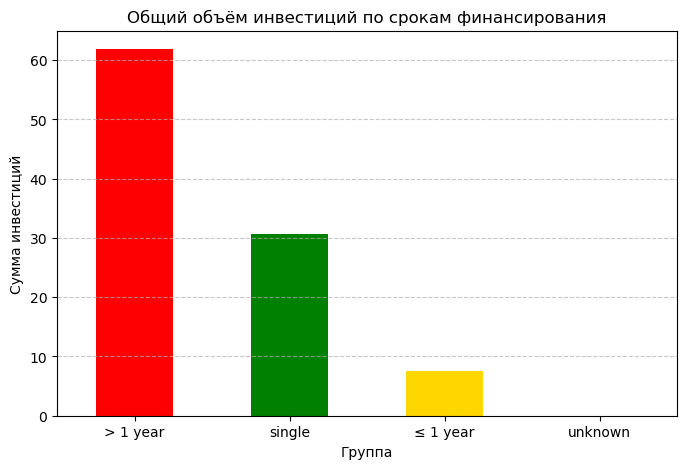

In [41]:
share_funding.plot(
    kind='bar',
    rot=0,
    figsize=(8,5),
    title='Общий объём инвестиций по срокам финансирования',
    color=[colors[i] for i in share_funding.index]
)

plt.ylabel('Сумма инвестиций')
plt.xlabel('Группа')
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()

61.87% всех инвестиций приходится на компании с длительным сроком финансирования (> 1 year). В этой категории (> 1 year) 25.5% компаний.

Что это означает, что долгосрочные компании:
- проходят больше раундов
- требуют больше капитала
- являются основными получателями инвестиций

Компании с одним раундом многочисленны, но получают существенно меньше средств (30.62%)

Несмотря на то, что большинство компаний ограничивается одним раундом финансирования, основная часть инвестиционного капитала сосредоточена в компаниях с длительным сроком финансирования. Это свидетельствует о том, что крупные инвестиции направляются в проекты, проходящие несколько стадий развития и имеющие долгосрочную стратегию роста.

## 2.2 Выделение средних и нишевых сегментов рынка

Создадим Series market_counts, в которой будут названия сегментов и их количество


In [42]:
market_counts = cb_investments['market'].value_counts()

market_counts.head()

market
software         5489
biotechnology    3761
mobile           2725
e-commerce       2283
curated web      2088
Name: count, dtype: int64

Разделим сегменты на группы

Сегменты, к которым относится более 120 компаний, отнесем к массовым, сегменты, в которые входит от 35 до 120 включительно, отнесем к средним, а сегменты до 35 компаний отнесем к нишевым.

In [43]:
def segment_type(count):
    if count > 120:
        return 'mass'
    elif 35 <= count <= 120:
        return 'mid'
    else:
        return 'niche'


market_type = market_counts.apply(segment_type)

In [44]:
# Посмотрим сколько сегментов в каждой группе
market_type.value_counts()

count
niche    334
mass      53
mid       52
Name: count, dtype: int64

Построим график распределения сегментов

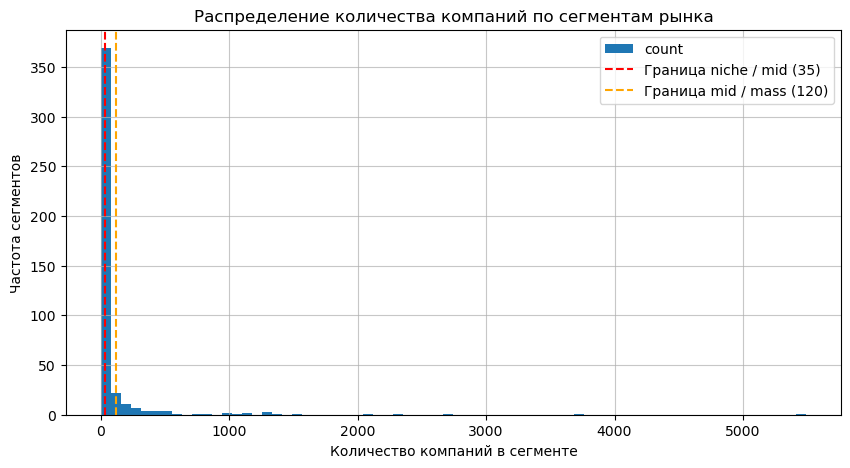

In [45]:
plt.figure(figsize=(10,5))

market_counts.plot(
    kind='hist',
    bins=70,
    title='Распределение количества компаний по сегментам рынка'
)

# границы сегментов
plt.axvline(35, color='red', linestyle='--', label='Граница niche / mid (35)')
plt.axvline(120, color='orange', linestyle='--', label='Граница mid / mass (120)')

plt.xlabel('Количество компаний в сегменте')
plt.ylabel('Частота сегментов')
plt.legend()

plt.grid(alpha=0.7)

plt.show()

Чтобы лучше показать нишевые и средние сегменты, ограничим ось X и увеличим количество интервалов

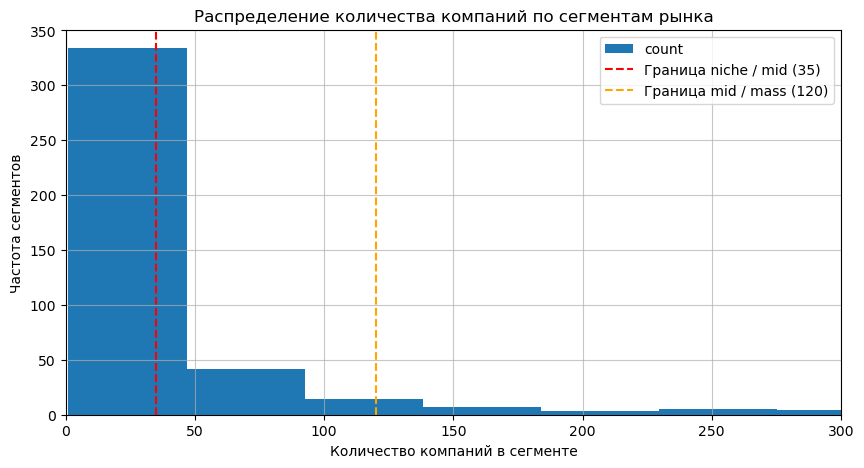

In [46]:
plt.figure(figsize=(10,5))

market_counts.plot(
    kind='hist',
    bins=120,
    title='Распределение количества компаний по сегментам рынка'
)

plt.axvline(35, color='red', linestyle='--', label='Граница niche / mid (35)')
plt.axvline(120, color='orange', linestyle='--', label='Граница mid / mass (120)')

plt.xlim(0, 300)

plt.xlabel('Количество компаний в сегменте')
plt.ylabel('Частота сегментов')
plt.legend()
plt.grid(alpha=0.7)



plt.show()

На графике видно:
- Большинство сегментов - нишевые
- Средних сегментов - значительно меньше
- Массовые сегменты - встречаются очень редко



Оставим в столбце market только массовые сегменты. Для остальных сегментов заменим значения на заглушки — niche для нишевых и mid для средних.

In [47]:
cb_investments['market'] = cb_investments['market'].replace(
    market_type[market_type != 'mass']
)

Подавляющее большинство сегментов относится к нишевым и включает менее 35 компаний. Средние сегменты встречаются значительно реже, а массовые сегменты составляют минимальную долю. Это свидетельствует о высокой фрагментированности рынка и наличии большого числа узкоспециализированных направлений.

После укрупнения сегментов структура признака market стала более компактной и удобной для анализа: редкие сегменты были объединены в категории mid и niche, а массовые сегменты сохранены в исходном виде. Это позволило уменьшить количество уникальных значений и сделать дальнейшее исследование более устойчивым и интерпретируемым.

# 3. Работа с выбросами и анализ

## 3.1. Анализируем и помечаем выбросы в каждом из сегментов

Посмотрим на распределения финансирования (млн $)

In [48]:
(cb_investments['funding_total_usd'] / 1000000).describe()

count    40907.000000
mean        15.912526
std        168.678800
min          0.000001
25%          0.350000
50%          2.000000
75%         10.000000
max      30079.503000
Name: funding_total_usd, dtype: float64

- median = 2 млн  
- mean = 15.9 млн

Значит есть небольшое число компаний с огромным финансированием


Интервал 0.35 млн – 10 млн $ - основная масса компаний

75% компаний получили до 10 млн $, половина - до 2 млн $

максимум - более 30 млрд $ - это экстремальные значения

Очень высокий разброс
- std = 168 млн 
- mean = 15.9 млн

значит данные крайне неоднородны


Рынок финансирования характеризуется высокой концентрацией капитала: большинство компаний привлекает относительно небольшие суммы (до 10 млн долларов), тогда как значительная часть общего объёма инвестиций сосредоточена в небольшом числе компаний с экстремально высокими значениями финансирования.

Используем Boxplot для оценки типичного размера общего финансирования для одной компании. Для корректного обображения ограничим данные по IQR

In [49]:
q1 = cb_investments['funding_total_usd'].quantile(0.25)
q3 = cb_investments['funding_total_usd'].quantile(0.75)
iqr = q3 - q1

upper = q3 + 1.5 * iqr

filtered = cb_investments['funding_total_usd'][
    cb_investments['funding_total_usd'] <= upper
]

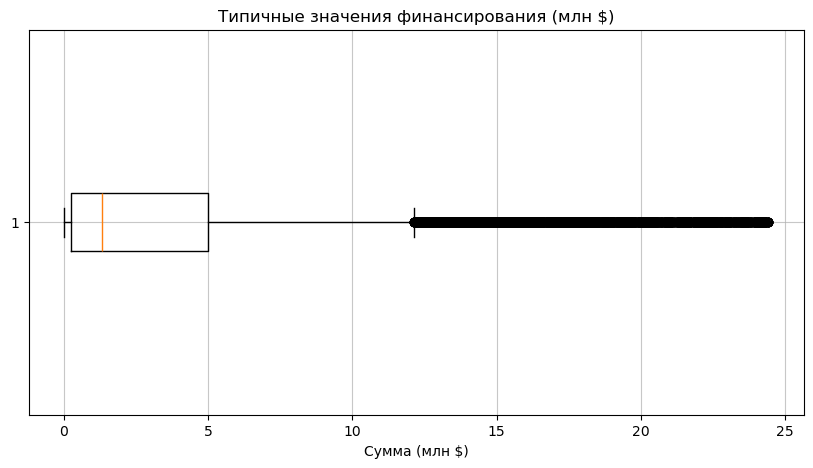

In [50]:
plt.figure(figsize=(10,5))

plt.boxplot(filtered / 1e6, vert=False)

plt.title('Типичные значения финансирования (млн $)')
plt.xlabel('Сумма (млн $)')
plt.grid(alpha=0.7)

plt.show()

Основная часть данных (межквартильный размах (IQR)) ~0.3 млн - ~5 млн $

типичное значение (медиана) - ~2 млн $

Более 12 млн - аномальные значения

Распределение общего объёма финансирования имеет выраженную правостороннюю асимметрию: большинство компаний привлекает относительно небольшие суммы, тогда как значительное число наблюдений приходится на высокие значения, формирующие длинный правый хвост. Типичные значения финансирования находятся в диапазоне от 0.35 до 10 млн долларов (межквартильный размах), при медиане около 2 млн долларов. Значения, превышающие примерно 10–12 млн долларов, можно отнести к аномальным, так как они существенно выходят за пределы основной массы наблюдений.

Посмотрим теперь на аномалии по сегментам, используя метод IQR отдельно по каждому сегменту

In [51]:
# Функция для поиска аномалий (IQR внутри группы)
def detect_outliers(group):
    q1 = group['funding_total_usd'].quantile(0.25)
    q3 = group['funding_total_usd'].quantile(0.75)
    iqr = q3 - q1

    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr

    return (group['funding_total_usd'] < lower) | (group['funding_total_usd'] > upper)

In [52]:
# Применяем функцию по сегментам:
cb_investments['is_outlier'] = (
    cb_investments
    .groupby('market', group_keys=False)
    .apply(detect_outliers, include_groups=False)
)

# присваем столбцу is_outlier тип bool
cb_investments['is_outlier'] = (
    cb_investments['is_outlier']
    .astype('boolean')
    .fillna(False)
    
)

In [53]:
outlier_share = (
    cb_investments
    .groupby('market')['is_outlier']
    .mean()
    .sort_values(ascending=False)
)

Сегменты рынка с наибольшей долей компаний, получивших аномальное финансирование (топ-10)

In [54]:
outlier_share.head(10)

market
medical devices    0.155738
cloud computing    0.147059
technology         0.139194
big data           0.138554
search             0.134831
saas               0.132132
photography        0.130435
video              0.128205
marketplaces        0.12766
internet           0.124161
Name: is_outlier, dtype: Float64

Большинство сегментов - технологические рынки

При этом лидер - medical devices. Значит не только IT привлекает крупные инвестиции

Также здесь есть нНеочевидные сегменты - photography, video

Типичные значения финансирования находятся в диапазоне от 0.35 до 10 млн долларов (межквартильный размах), при медиане около 2 млн долларов

Наибольшая доля компаний с аномально высоким объёмом финансирования наблюдается как в технологических сегментах (cloud computing, big data, saas), так и в отдельных высокотехнологичных направлениях, таких как medical devices. Это свидетельствует о том, что крупные инвестиции концентрируются не только в цифровых продуктах, но и в капиталоёмких инновационных отраслях, связанных с медициной и технологиями.

## 3.2. Определяем границы рассматриваемого периода, отбрасываем аномалии

Посмотрим на распределение распределение по месяцам за 2014 год:

In [55]:
cb_investments['mid_year'] = cb_investments['mid_funding_at'].dt.year

cb_investments['mid_month'] = cb_investments['mid_funding_at'].dt.month

cb_investments[
    cb_investments['mid_year'] == 2014
]['mid_month'].value_counts().sort_index()

mid_month
1.0     1013
2.0      750
3.0      829
4.0      818
5.0      774
6.0      932
7.0      874
8.0      774
9.0      699
10.0     651
11.0     362
12.0      30
Name: count, dtype: int64

Есть данные по всем 12 месяцам за 2014 год. Однако наблюдается снижение числа записей в последние месяцы: в ноябре и особенно в декабре количество сделок резко уменьшается.

Посмотрим на количество сделок по годам:

In [56]:
cb_investments['mid_year'].value_counts().sort_index()

mid_year
1921.0        1
1960.0        3
1973.0        1
1974.0        2
1979.0        1
1982.0        3
1983.0        1
1984.0        5
1985.0        5
1986.0        4
1987.0        6
1988.0        2
1989.0        4
1990.0       12
1991.0        9
1992.0       12
1993.0       14
1994.0       12
1995.0       18
1996.0       24
1997.0       20
1998.0       45
1999.0       93
2000.0      148
2001.0       91
2002.0      111
2003.0      131
2004.0      205
2005.0      917
2006.0     1595
2007.0     2413
2008.0     2990
2009.0     3680
2010.0     4685
2011.0     5935
2012.0     7470
2013.0    10256
2014.0     8506
Name: count, dtype: int64

До 2013 года - стабильный рост

В 2014 году - тренд меняется, происходит резкое падение

За 2014 год информация представлена неравномерно: в последние месяцы наблюдается снижение числа записей, что может свидетельствовать о частичной неполноте данных. Однако данные присутствуют для всех месяцев года и покрывают большую часть периода, поэтому 2014 год был сохранён в анализе с учётом возможного влияния неполноты данных.

Исключим из датасета компании, которые мы посчитали получившими аномальное финансирование:

In [57]:
cb_investments = cb_investments[~cb_investments['is_outlier'].fillna(False)]

In [58]:
cb_investments['is_outlier'].value_counts(dropna=False)

is_outlier
False    44579
Name: count, dtype: Int64

Столбец is_outlier теперь можно удалить

In [59]:
cb_investments = cb_investments.drop(columns='is_outlier')

На основе столбцов mid_funding_at и funding_rounds оставим в датасете данные только об определённых компаниях. Они должны были получать финансирование в годы, когда было зафиксировано 50 или более раундов финансирования.

In [60]:

# считаем общее число раундов финансирования по годам
rounds_per_year = cb_investments.groupby('mid_year')['funding_rounds'].sum()

# оставляем только годы, где было 50 или более раундов
valid_years = rounds_per_year[rounds_per_year >= 50].index

# фильтруем датасет
cb_investments = cb_investments[cb_investments['mid_year'].isin(valid_years)]

Из исходного датасета были исключены компании с аномальным объёмом финансирования, после чего анализ проводился только на очищенных данных.

Из датасета были удалены данные за годы, в которых было зафиксировано менее 50 раундов финансирования

## 3.3. Анализ типов финансирования по объёму и популярности

Построим график, который покажет, какие типы финансирования в сумме привлекли больше всего денег.

Будем ориентироваться на значения в столбцах seed, venture, equity_crowdfunding, undisclosed, convertible_note, debt_financing, angel, grant, private_equity, post_ipo_equity, post_ipo_debt, secondary_market и product_crowdfunding.

In [61]:
#Создаем список столбцов
cols = [
    'seed', 'venture', 'equity_crowdfunding', 'undisclosed',
    'convertible_note', 'debt_financing', 'angel', 'grant',
    'private_equity', 'post_ipo_equity', 'post_ipo_debt',
    'secondary_market', 'product_crowdfunding'
]

In [62]:
# Суммируем по типам финансирования в млн $:
funding_sum = cb_investments[cols].sum().sort_values(ascending=False) / 1e6

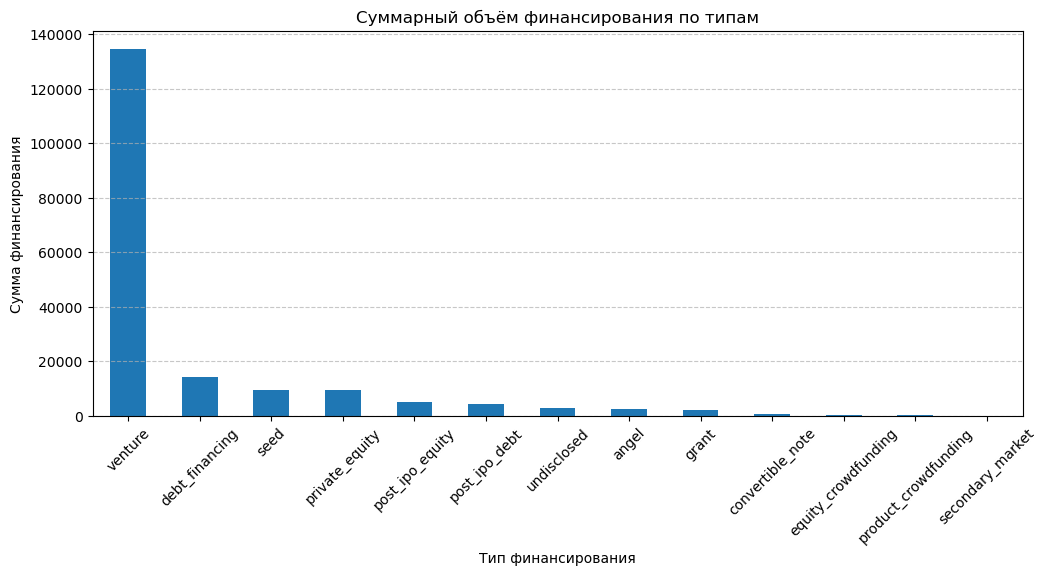

In [63]:
# Строим график:

plt.figure(figsize=(10,5))
funding_sum.plot(
    kind='bar',
    figsize=(12,5),
    title='Суммарный объём финансирования по типам'
)

plt.ylabel('Сумма финансирования')
plt.xlabel('Тип финансирования')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()

По объему финансирования venture — абсолютный лидер

Дальше (с большим отрывом):

- debt_financing
- private_equity
- seed

остальные - существенно меньше

Это свидетельствует о высокой концентрации капитала в нескольких основных инструментах финансирования.

Посмотрим теперь на популярность разных типов финансирования — какие типы финансирования чаще всего используются компаниями, то есть встречаются в датасете наибольшее количество раз

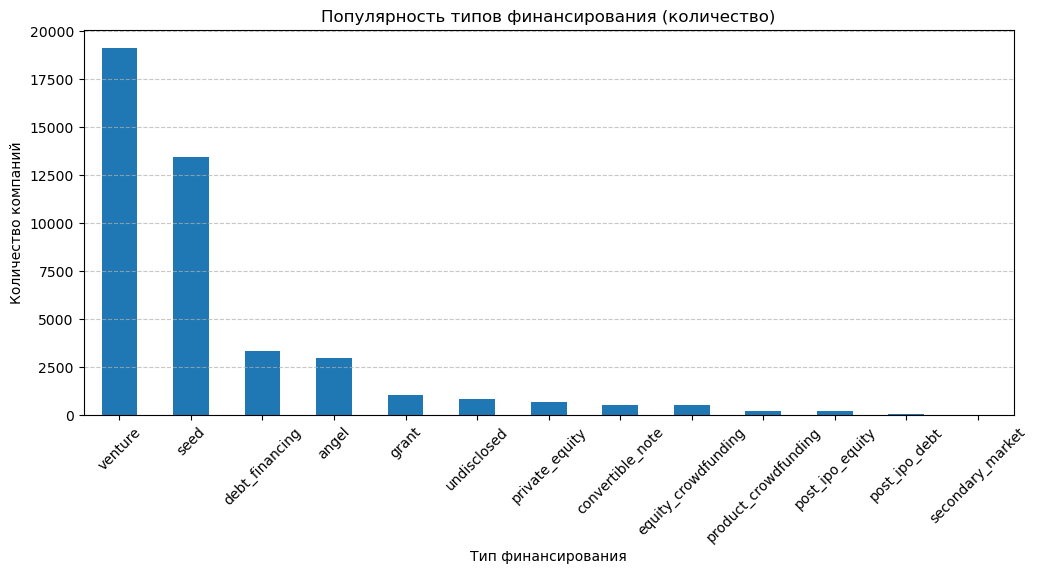

In [64]:
funding_count = (
    (cb_investments[cols] > 0)
    .sum()
    .sort_values(ascending=False)
)

plt.figure(figsize=(10,5))

funding_count.plot(
    kind='bar',
    figsize=(12,5),
    title='Популярность типов финансирования (количество)'
)

plt.ylabel('Количество компаний')
plt.xlabel('Тип финансирования')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()

Наиболее распространёнными являются венчурное (venture) и посевное (seed) финансирование. Также относительно часто используются debt_financing и angel. Это указывает на то, что большинство компаний сначала привлекают небольшие деньги (seed, angel), а до крупных инвестиций доходят далеко не все

Различные типы финансирования существенно различаются по частоте использования и объёму привлечённых средств. Ранние стадии финансирования, такие как seed и angel, используются наиболее часто, однако характеризуются относительно небольшими объёмами инвестиций. В то же время такие инструменты, как private equity и post-IPO финансирование, встречаются значительно реже, но обеспечивают крупнейшие объёмы вложений. Венчурное финансирование занимает ключевое положение на рынке, сочетая высокую частоту использования с наибольшим объёмом привлечённых средств.

Посмотрим суммарные объёмоы возвратов от разных типов финансирования за весь период на основе дополнительного датасета.

In [65]:
returns_sum = (
    cb_returns
    .sum()
    .sort_values(ascending=False)
)

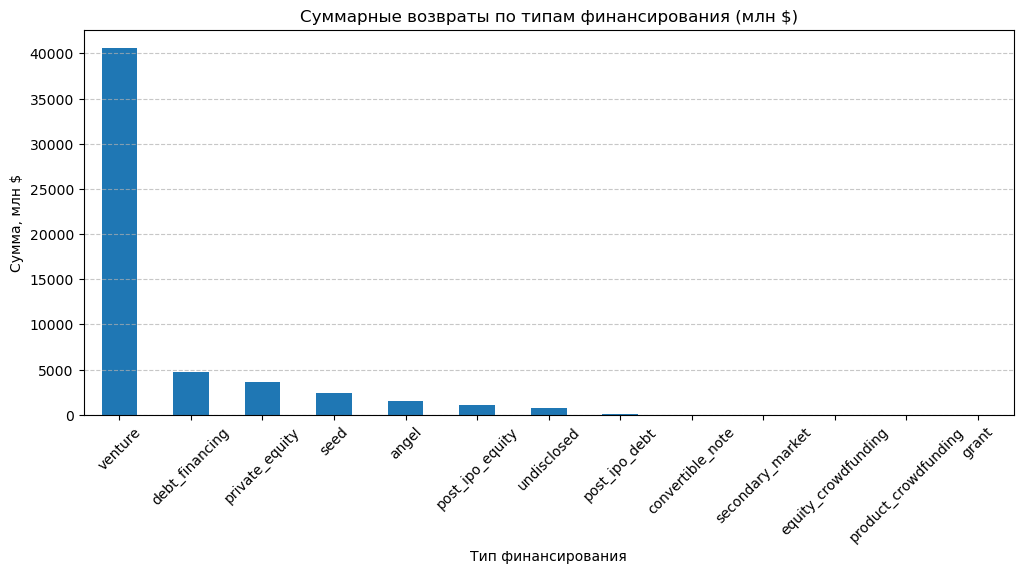

In [66]:
returns_sum.plot(
    kind='bar',
    figsize=(12,5),
    title='Суммарные возвраты по типам финансирования (млн $)'
)

plt.ylabel('Сумма, млн $')
plt.xlabel('Тип финансирования')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()

Основная часть возвратов приходится на венчурное финансирование, что подтверждает его ключевую роль на рынке. При этом более крупные и поздние стадии инвестирования также обеспечивают значительные возвраты, тогда как ранние стадии характеризуются существенно меньшими объёмами.


Основной объём инвестиций и возвратов сосредоточен в венчурном финансировании, тогда как ранние стадии используются чаще, но дают меньший финансовый эффект. Крупные прибыли формируются за счёт относительно небольшого числа сделок на поздних стадиях.

# 4. Анализ динамики

## 4.1 Динамика предоставления финансирования по годам

Расчитаем для каждой компании средний объём одного раунда финансирования

In [67]:
cb_investments['avg_round'] = (
    cb_investments['funding_total_usd'] / cb_investments['funding_rounds']
)

Расчитаем типичный размер раунда (по годам), используя медиану

In [68]:
avg_round_year = (
    cb_investments
    .groupby('mid_year')['avg_round']
    .median() / 1e6   # в млн $
)

Строим график, отображающий типичный размер раунда (по годам)

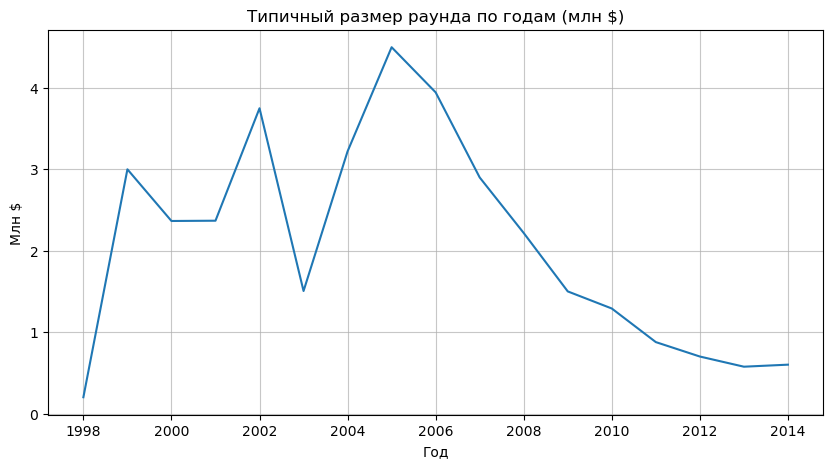

In [69]:
avg_round_year.plot(
    figsize=(10,5),
    title='Типичный размер раунда по годам (млн $)'
)

plt.ylabel('Млн $')
plt.xlabel('Год')
plt.grid(alpha=0.7)

plt.show()

Типичный размер одного раунда финансирования достиг максимума в 2005 году, после чего наблюдается устойчивая тенденция к снижению. К 2014 году средний размер раунда значительно уменьшился и оказался на одном из самых низких уровней.

Расчитаем количество раундов по годам

In [70]:
rounds_per_year = (
    cb_investments
    .groupby('mid_year')['funding_rounds']
    .sum()
)

Построим график количества раундов по каждому году

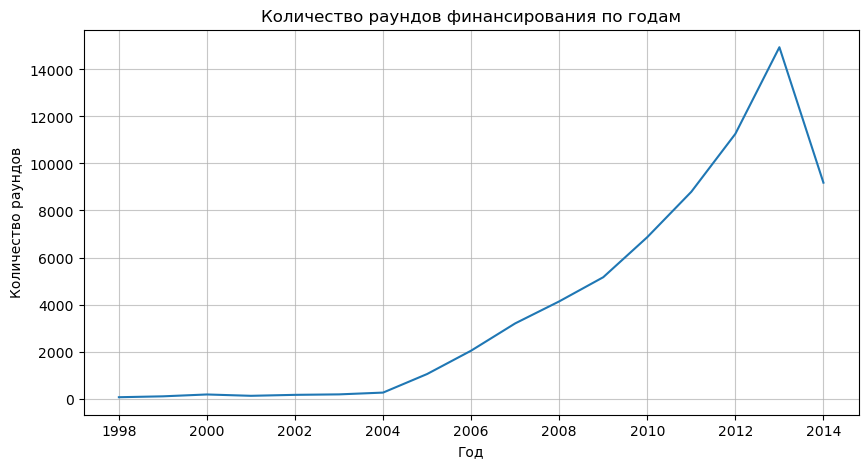

In [71]:
rounds_per_year.plot(
    figsize=(10,5),
    title='Количество раундов финансирования по годам'
)

plt.ylabel('Количество раундов')
plt.xlabel('Год')
plt.grid(alpha=0.7)

plt.show()

Количество раундов финансирования с течением времени значительно увеличивается. Особенно заметный рост начинается после 2004 года, после чего инвестиционная активность на рынке резко возрастает и достигает пика в 2013 году.

В 2014 году наблюдается снижение количества раундов по сравнению с предыдущим годом. Это может свидетельствовать либо о снижении инвестиционной активности, либо о неполноте данных за этот период.

С середины 2000-х годов количество раундов финансирования значительно увеличивается, что свидетельствует о росте инвестиционной активности на рынке. При этом типичный размер одного раунда после пика в 2005 году постепенно снижается.

Это означает, что рынок становится более массовым: количество сделок растёт, но средний объём средств, привлекаемых в рамках одного раунда, уменьшается.

В 2014 году наблюдается снижение количества раундов при сохранении низкого среднего размера финансирования, что может быть связано с частичной неполнотой данных за этот период.

## 4.2 Динамика размера общего финансирования по массовым сегментам рынка для растущих в 2014 году сегментов

Создадим сводную таблицу, в которой указывается суммарный размер общего финансирования funding_total_usd по годам и сегментам рынка. Рассматриваем при этом только массовые сегменты

In [72]:
# Оставим только массовые сегменты
cb_mass = cb_investments[
    ~cb_investments['market'].isin(['mid', 'niche'])
]

In [73]:
# Создаем сводную таблицу
pivot = (
    cb_mass
    .pivot_table(
        index='mid_year',
        columns='market',
        values='funding_total_usd',
        aggfunc='sum'
    )
)

pivot

market,advertising,analytics,apps,automotive,big data,biotechnology,clean technology,cloud computing,consulting,curated web,...,social media,social network media,software,sports,startups,technology,transportation,travel,video,web hosting
mid_year,,,,,,,,,,,,,,,,,,,,,
1998.0,NaN,NaN,NaN,NaN,NaN,0.000000e+00,NaN,NaN,100000.0,1600000.0,...,NaN,NaN,1.082679e+07,NaN,NaN,NaN,NaN,NaN,NaN,0.0
1999.0,350000.0,10774916.0,NaN,NaN,NaN,NaN,NaN,NaN,115200.0,9250000.0,...,0.0,NaN,2.903464e+07,NaN,NaN,6000000.0,NaN,0.0,NaN,3600000.0
2000.0,14470000.0,14822803.0,NaN,NaN,NaN,NaN,NaN,11500000.0,4500000.0,1000000.0,...,NaN,NaN,3.173264e+07,NaN,NaN,NaN,NaN,50230.0,NaN,95343090.0
2001.0,8778321.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,0.0,305000.0,...,650000.0,NaN,2.781135e+07,NaN,NaN,22160000.0,6779357.0,NaN,NaN,15000000.0
2002.0,24500000.0,7500000.0,NaN,NaN,NaN,NaN,3.439044e+07,NaN,NaN,4650000.0,...,NaN,NaN,1.010264e+08,200000.0,NaN,11000000.0,NaN,NaN,NaN,0.0
2003.0,10500000.0,3840000.0,NaN,4530000.0,NaN,8.553118e+07,5.035294e+07,NaN,NaN,2550000.0,...,5000.0,NaN,6.608604e+07,NaN,NaN,NaN,15000000.0,NaN,5000000.0,NaN
2004.0,6000000.0,3000000.0,NaN,NaN,NaN,9.718486e+07,5.042795e+07,NaN,NaN,27050000.0,...,6850000.0,NaN,1.408238e+08,NaN,NaN,1750000.0,22600000.0,10230000.0,14704000.0,27000000.0
2005.0,127196022.0,79014044.0,NaN,22500000.0,NaN,4.800636e+08,1.942000e+07,0.0,44862000.0,53450000.0,...,14780000.0,5200000.0,9.930766e+08,1882200.0,NaN,50728425.0,NaN,27830000.0,6470551.0,483332632.0
2006.0,299299458.0,139701311.0,1310600.0,12660000.0,NaN,9.035005e+08,1.314739e+08,9951809.0,23965548.0,164673698.0,...,60169880.0,5245100.0,1.646869e+09,7000000.0,NaN,22791000.0,17400000.0,11700000.0,35171772.0,649959267.0


Отберем из неё только те сегменты, которые показывали рост размера суммарного финансирования в 2014 году по сравнению с 2013

In [74]:
growth_segments = pivot.loc[2014] > pivot.loc[2013]
selected_segments = growth_segments[growth_segments].index

In [75]:
pivot_selected = pivot[selected_segments]

pivot_selected

market,apps,big data,design,financial services,internet,manufacturing,media,medical,medical devices,real estate,saas,startups,technology
mid_year,,,,,,,,,,,,,
1998.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1999.0,NaN,NaN,NaN,NaN,0.0,0.0,NaN,NaN,NaN,250000.0,NaN,NaN,6000000.0
2000.0,NaN,NaN,NaN,NaN,10000000.0,56659310.0,NaN,24000000.0,8500000.0,2500000.0,NaN,NaN,NaN
2001.0,NaN,NaN,0.0,NaN,NaN,2368582.0,NaN,NaN,NaN,NaN,NaN,NaN,22160000.0
2002.0,NaN,NaN,NaN,NaN,1100000.0,NaN,NaN,NaN,NaN,5275000.0,2000000.0,NaN,11000000.0
2003.0,NaN,NaN,0.0,NaN,NaN,4269608.0,NaN,0.0,2043272.0,6292200.0,NaN,NaN,NaN
2004.0,NaN,NaN,NaN,0.0,10500000.0,3000000.0,2000000.0,NaN,0.0,NaN,NaN,NaN,1750000.0
2005.0,NaN,NaN,9300000.0,15183352.0,1775000.0,61770000.0,NaN,11090000.0,NaN,250000.0,5240000.0,NaN,50728425.0
2006.0,1310600.0,NaN,707000.0,NaN,5000.0,163957751.0,22638757.0,20250000.0,3500000.0,2080000.0,4791121.0,NaN,22791000.0


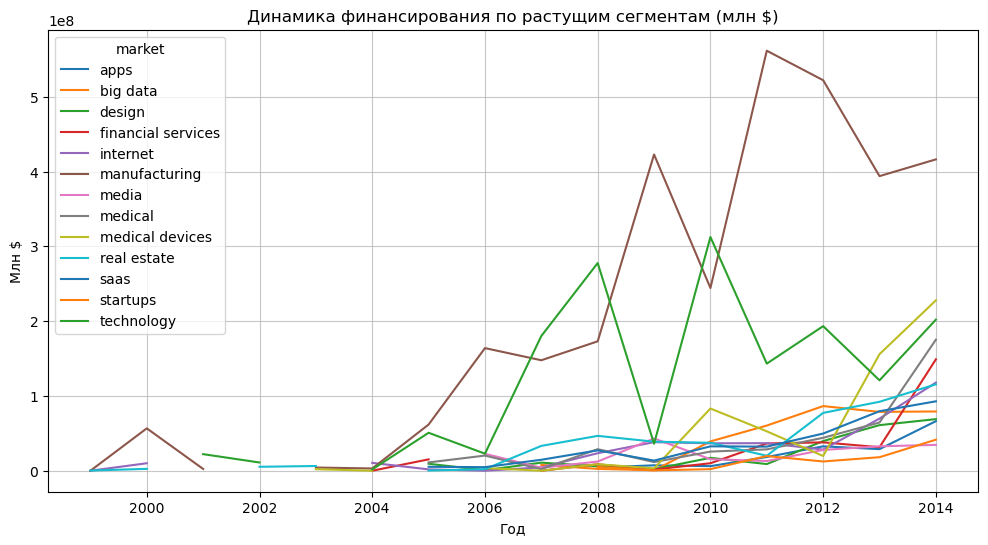

In [76]:
pivot_selected.plot(
    figsize=(12,6),
    title='Динамика финансирования по растущим сегментам (млн $)'
)

plt.ylabel('Млн $')
plt.xlabel('Год')
plt.grid(alpha=0.7)

plt.show()

Среди массовых сегментов наблюдается неравномерная динамика роста финансирования: часть сегментов демонстрирует резкий и волатильный рост, тогда как другие растут более стабильно и предсказуемо.

явно выделяются:

- manufacturing - самый высокий уровень финансирования
- technology - сильные пики, но нестабильность

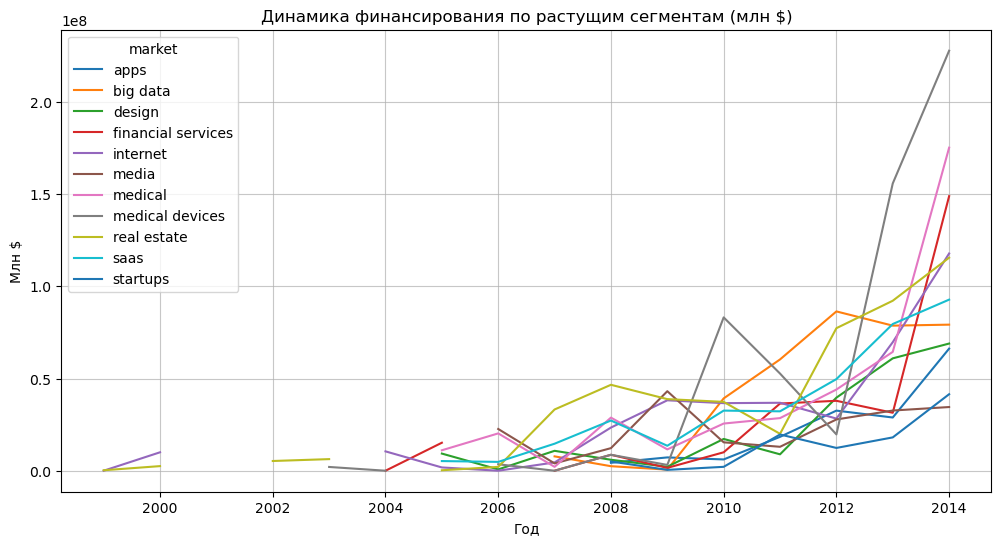

In [77]:
pivot_selected.drop(columns=['manufacturing', 'technology'], errors='ignore').plot(
    figsize=(12,6),
    title='Динамика финансирования по растущим сегментам (млн $)'
)

plt.ylabel('Млн $')
plt.xlabel('Год')
plt.grid(alpha=0.7)

plt.show()

После исключения сегментов manufacturing и technology становится видно, что рост финансирования в остальных сегментах происходит более равномерно, без резких скачков.

Сегменты с самым быстрым ростом:

- medical devices — самый сильный скачок
- medical — устойчивый рост с ускорением
- financial services — быстрый рост в конце периода

Более плавные линии:

- saas
- real estate
- big data

Наиболее быстрый рост показывают сегменты manufacturing и technology, однако их динамика нестабильна и сопровождается резкими колебаниями.

Также быстрый и стабильный рост демонстрируют сегменты medical devices и medical, особенно в последние годы, что может свидетельствовать о повышенном интересе инвесторов к медицинским и технологическим решениям в этой области. При этом такие сегменты, как saas и real estate, показывают более устойчивый и предсказуемый рост, что говорит о стабильном спросе со стороны инвесторов.

## 4.3 Годовая динамика доли возвращённых средств по типам финансирования

Расчитаем сумму инвестиций по годам для 'venture', 'debt_financing', 'private_equity', 'seed', 'angel'

In [78]:
funding_year = (
    cb_investments
    .groupby('mid_year')[[
        'venture', 'debt_financing', 'private_equity', 'seed', 'angel'
    ]]
    .sum()
)

Расчитаем нормированные значения возврата средств: то есть какую долю возвращённые средства составляют от предоставленных

In [79]:
normalized_returns = (
    cb_returns[['venture', 'debt_financing', 'private_equity', 'seed', 'angel']]
    / (funding_year + 1e-60)
)

normalized_returns

,venture,debt_financing,private_equity,seed,angel
1998.0,NaN,NaN,NaN,NaN,NaN
1999.0,NaN,NaN,NaN,NaN,NaN
2000.0,1.475908e-07,6.185714e-07,0.000000e+00,9.964712e-07,2.669564e-07
2001.0,8.235728e-08,7.702578e-07,0.000000e+00,1.090952e-07,1.180000e-06
2002.0,6.116901e-07,2.233882e-07,3.251376e-08,6.297066e-07,1.136667e-06
2003.0,5.843076e-07,1.038095e-06,1.620000e+60,5.052762e-07,6.057203e-07
2004.0,7.475631e-07,4.396978e-07,2.190000e+60,5.484755e-07,8.335043e-07
2005.0,5.361917e-07,3.449644e-07,4.800000e-07,6.746954e-07,5.098940e-07
2006.0,3.369507e-07,8.037720e-07,4.653793e-07,9.253718e-07,6.748530e-07
2007.0,2.929920e-07,1.910316e-07,4.534642e-07,3.661533e-07,8.178375e-07


Уберем аномально большие значения (где доля возврата >= 100%) и заменим их на Nan

In [80]:
normalized_returns = normalized_returns.where(normalized_returns < 1)
normalized_returns

,venture,debt_financing,private_equity,seed,angel
1998.0,NaN,NaN,NaN,NaN,NaN
1999.0,NaN,NaN,NaN,NaN,NaN
2000.0,1.475908e-07,6.185714e-07,0.000000e+00,9.964712e-07,2.669564e-07
2001.0,8.235728e-08,7.702578e-07,0.000000e+00,1.090952e-07,1.180000e-06
2002.0,6.116901e-07,2.233882e-07,3.251376e-08,6.297066e-07,1.136667e-06
2003.0,5.843076e-07,1.038095e-06,NaN,5.052762e-07,6.057203e-07
2004.0,7.475631e-07,4.396978e-07,NaN,5.484755e-07,8.335043e-07
2005.0,5.361917e-07,3.449644e-07,4.800000e-07,6.746954e-07,5.098940e-07
2006.0,3.369507e-07,8.037720e-07,4.653793e-07,9.253718e-07,6.748530e-07
2007.0,2.929920e-07,1.910316e-07,4.534642e-07,3.661533e-07,8.178375e-07


Построим график на основе этих данных

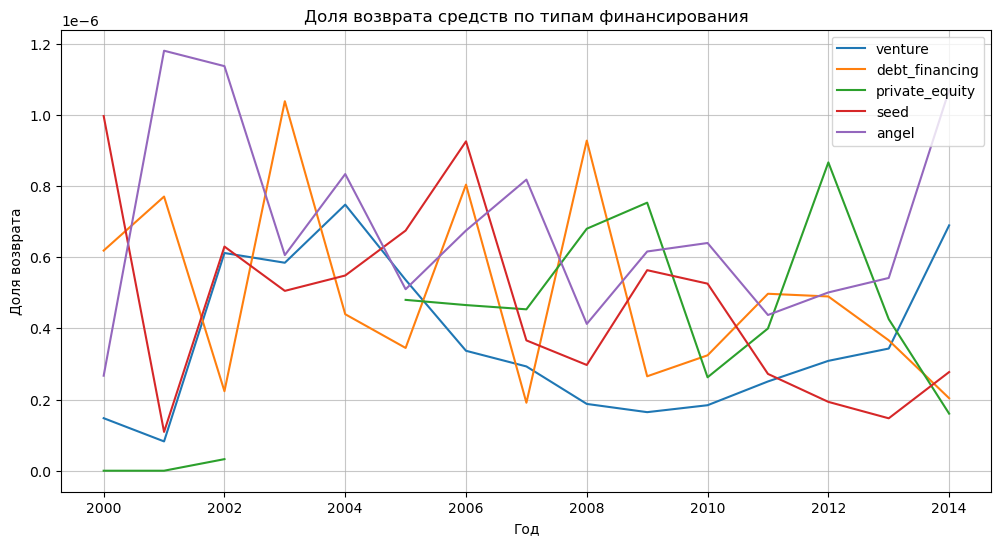

In [81]:
normalized_returns.plot(
    figsize=(12,6),
    title='Доля возврата средств по типам финансирования'
)

plt.ylabel('Доля возврата')
plt.xlabel('Год')
plt.grid(alpha=0.7)

plt.show()

Ни один из типов финансирования не демонстрирует строго устойчивого и монотонного роста доли возврата средств — для всех характерны колебания.

- venture - после 2008 идёт постепенный рост, к 2014 достигает одного из максимумов -самый близкий к устойчивому росту

- debt_financing - сильные колебания, нет явного тренда -нестабильный

- private_equity - скачки, нет плавной динамики - умеренно нестабильный

- angel - колебания, но иногда высокие значения, нет устойчивого тренда - нестабильный

- seed - общий тренд скорее снижение, сильная волатильность - самый слабый по возвратам


Наиболее устойчивую тенденцию к росту демонстрирует венчурное финансирование (venture), особенно в последние годы. Остальные типы финансирования характеризуются высокой волатильностью и отсутствием выраженного тренда, что указывает на менее предсказуемую динамику возвратов.

# 5. Итоговый вывод и рекомендации

Итоги проекта
1. Выполненные шаги

В ходе анализа были выполнены следующие этапы:

- проведена предобработка данных (обработка пропусков, выбросов, приведение форматов);
- рассчитаны показатели длительности финансирования и сегментации рынка;
- выделены массовые, средние и нишевые сегменты;
- проанализированы объёмы инвестиций и их распределение по типам финансирования;
- исследованы возвраты средств и рассчитаны нормированные показатели;
- изучена динамика количества раундов и среднего размера инвестиций;
- построены графики для выявления трендов по сегментам и типам финансирования.

2. Основные выводы
- рынок стал более массовым: количество сделок растёт, а средний размер инвестиций снижается;
- венчурное финансирование является ключевым элементом рынка по объёму, частоте и возвратам;
- ранние стадии (seed, angel) характеризуются высокой волатильностью и меньшей эффективностью;
- наиболее перспективные сегменты — медицинские технологии и SaaS, демонстрирующие устойчивый рост;
- возвраты средств в целом невелики относительно объёма инвестиций, что указывает на высокий риск рынка.

В целом результаты анализа согласуются между собой:

- рост количества раундов объясняет снижение среднего размера инвестиций;
- доминирование венчурного финансирования подтверждается как по объёму, так и по возвратам;

Однако некоторые выводы требуют осторожной интерпретации:

- данные за 2014 год могут быть неполными, что влияет на динамику;
- высокая волатильность отдельных показателей затрудняет выявление устойчивых трендов;
- нормированные возвраты имеют очень малые значения, что может ограничивать точность сравнения.

На основе проведённого анализа наиболее перспективными для инвестирования являются сегменты, связанные с медицинскими технологиями (medical, medical devices), а также направления, демонстрирующие стабильный рост, такие как SaaS.

Причины:

- эти сегменты показывают устойчивый рост финансирования
- интерес инвесторов к ним усиливается в последние годы
- отсутствуют резкие падения, характерные для более волатильных сегментов

Тип финансирования - наиболее уместным типом финансирования является венчурное финансирование (venture), т.к:

- демонстрирует наиболее устойчивый рост доли возвратов
- сочетает высокую распространённость и значительные объёмы инвестиций
- является основным инструментом масштабирования бизнеса